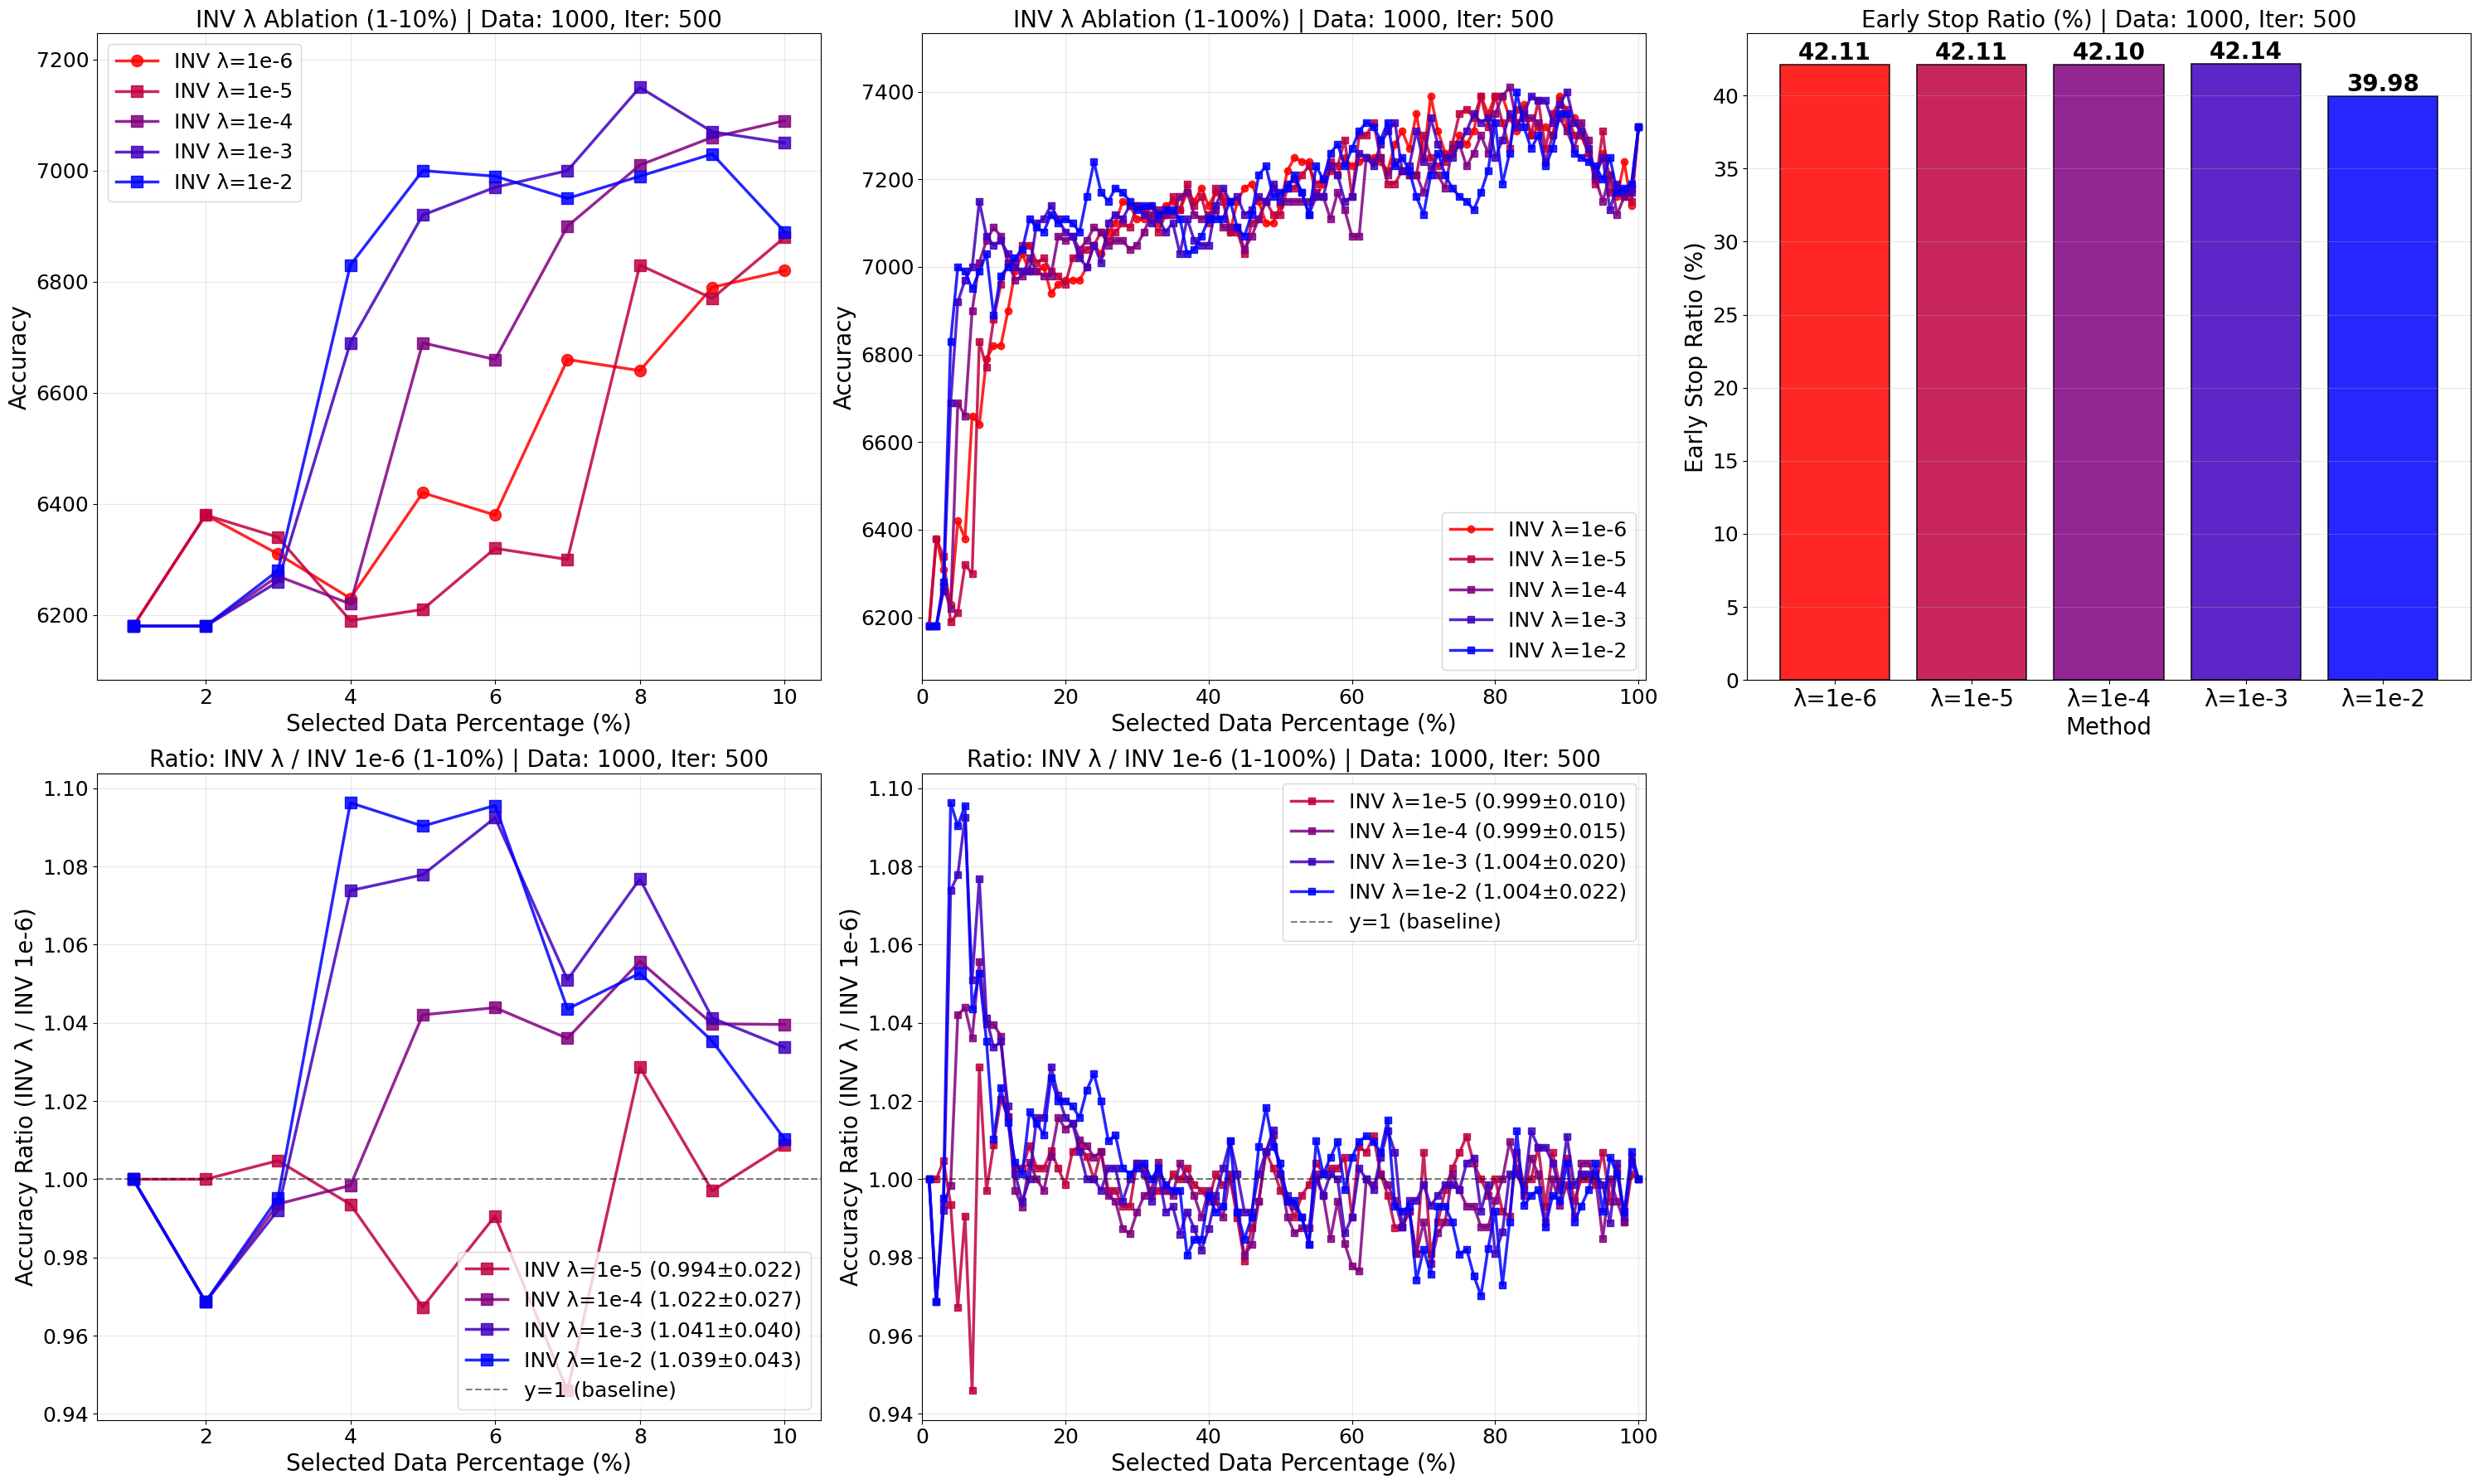

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 1000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [6180, 6380, 6310, 6230, 6420, 6380, 6660, 6640, 6790, 6820, 6820, 6900, 6990, 7030, 6990, 6990, 7000, 6940, 6960, 6970, 6970, 6970, 7000, 7050, 7030, 7080, 7100, 7150, 7140, 7110, 7110, 7140, 7100, 7140, 7150, 7130, 7170, 7150, 7180, 7140, 7170, 7160, 7080, 7150, 7180, 7190, 7150, 7100, 7100, 7140, 7220, 7250, 7240, 7240, 7160, 7190, 7220, 7210, 7250, 7230, 7240, 7250, 7250, 7240, 7220, 7280, 7310, 7270, 7350, 7250, 7390, 7310, 7260, 7260, 7300, 7280, 7310, 7390, 7350, 7390, 7390, 7340, 7310, 7370, 7300, 7320, 7320, 7300, 7390, 7320, 7340, 7300, 7260, 7200, 7260, 7210, 7160, 7240, 7140, 7320]
lam1e_5  = [6180, 6380, 6340, 6190, 6210, 6320, 6300, 6830, 6770, 6880, 6960, 7010, 7010, 7050, 7050, 7010, 7020, 6990, 6980, 6960, 7020, 7030, 7040, 7050, 7080, 7060, 7080, 7100, 7090, 7140, 7130, 7110, 7080, 7120, 7160, 7130, 7190, 7140, 7160, 7100, 7180, 7150, 7080, 7080, 7030, 7100, 7110, 7150, 7120, 7120, 7180, 7180, 7210, 7230, 7190, 7200, 7240, 7230, 7290, 7160, 7300, 7300, 7330, 7250, 7190, 7190, 7220, 7210, 7210, 7300, 7250, 7230, 7240, 7280, 7350, 7360, 7340, 7390, 7320, 7390, 7330, 7270, 7360, 7360, 7300, 7380, 7270, 7350, 7380, 7360, 7300, 7300, 7260, 7190, 7310, 7170, 7180, 7160, 7150, 7320]
lam1e_4  = [6180, 6180, 6270, 6220, 6690, 6660, 6900, 7010, 7060, 7090, 7070, 7010, 6970, 6980, 7020, 6990, 6980, 6980, 7070, 7060, 7070, 7040, 7060, 7090, 7080, 7050, 7060, 7060, 7040, 7050, 7080, 7120, 7130, 7120, 7120, 7160, 7170, 7120, 7110, 7120, 7130, 7090, 7090, 7090, 7040, 7070, 7110, 7150, 7180, 7150, 7150, 7150, 7150, 7150, 7170, 7160, 7110, 7170, 7130, 7070, 7070, 7250, 7240, 7250, 7210, 7240, 7220, 7210, 7210, 7170, 7230, 7210, 7180, 7270, 7280, 7230, 7260, 7300, 7260, 7350, 7390, 7410, 7330, 7340, 7340, 7330, 7240, 7300, 7340, 7310, 7270, 7330, 7290, 7200, 7150, 7210, 7120, 7160, 7180, 7320]
lam1e_3  = [6180, 6180, 6260, 6690, 6920, 6970, 7000, 7150, 7070, 7050, 7060, 7030, 7000, 6990, 6990, 7100, 7110, 7140, 7110, 7080, 7070, 7020, 7000, 7050, 7010, 7100, 7120, 7110, 7140, 7140, 7120, 7100, 7110, 7080, 7100, 7030, 7110, 7060, 7050, 7050, 7140, 7180, 7150, 7160, 7120, 7130, 7160, 7150, 7190, 7150, 7190, 7200, 7170, 7120, 7160, 7160, 7230, 7210, 7150, 7160, 7260, 7250, 7230, 7280, 7310, 7330, 7220, 7230, 7310, 7240, 7340, 7280, 7250, 7250, 7280, 7310, 7350, 7330, 7340, 7250, 7290, 7350, 7320, 7350, 7390, 7380, 7380, 7330, 7370, 7400, 7330, 7310, 7270, 7210, 7250, 7130, 7190, 7170, 7170, 7320]
lam1e_2  = [6180, 6180, 6280, 6830, 7000, 6990, 6950, 6990, 7030, 6890, 6980, 7000, 7020, 7040, 7110, 7090, 7080, 7120, 7100, 7110, 7100, 7080, 7160, 7240, 7170, 7150, 7180, 7170, 7150, 7130, 7140, 7140, 7120, 7130, 7130, 7110, 7030, 7040, 7070, 7110, 7110, 7110, 7150, 7090, 7070, 7120, 7210, 7230, 7160, 7170, 7180, 7210, 7170, 7120, 7230, 7200, 7260, 7280, 7230, 7270, 7310, 7330, 7320, 7290, 7330, 7230, 7250, 7220, 7160, 7120, 7210, 7260, 7210, 7180, 7160, 7150, 7130, 7170, 7220, 7330, 7190, 7260, 7400, 7320, 7270, 7300, 7230, 7270, 7350, 7350, 7260, 7250, 7240, 7230, 7200, 7250, 7170, 7180, 7190, 7320]

lam1e_6_early_stop = [42.11]
lam1e_5_early_stop = [42.11]
lam1e_4_early_stop = [42.10]
lam1e_3_early_stop = [42.14]
lam1e_2_early_stop = [39.98]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

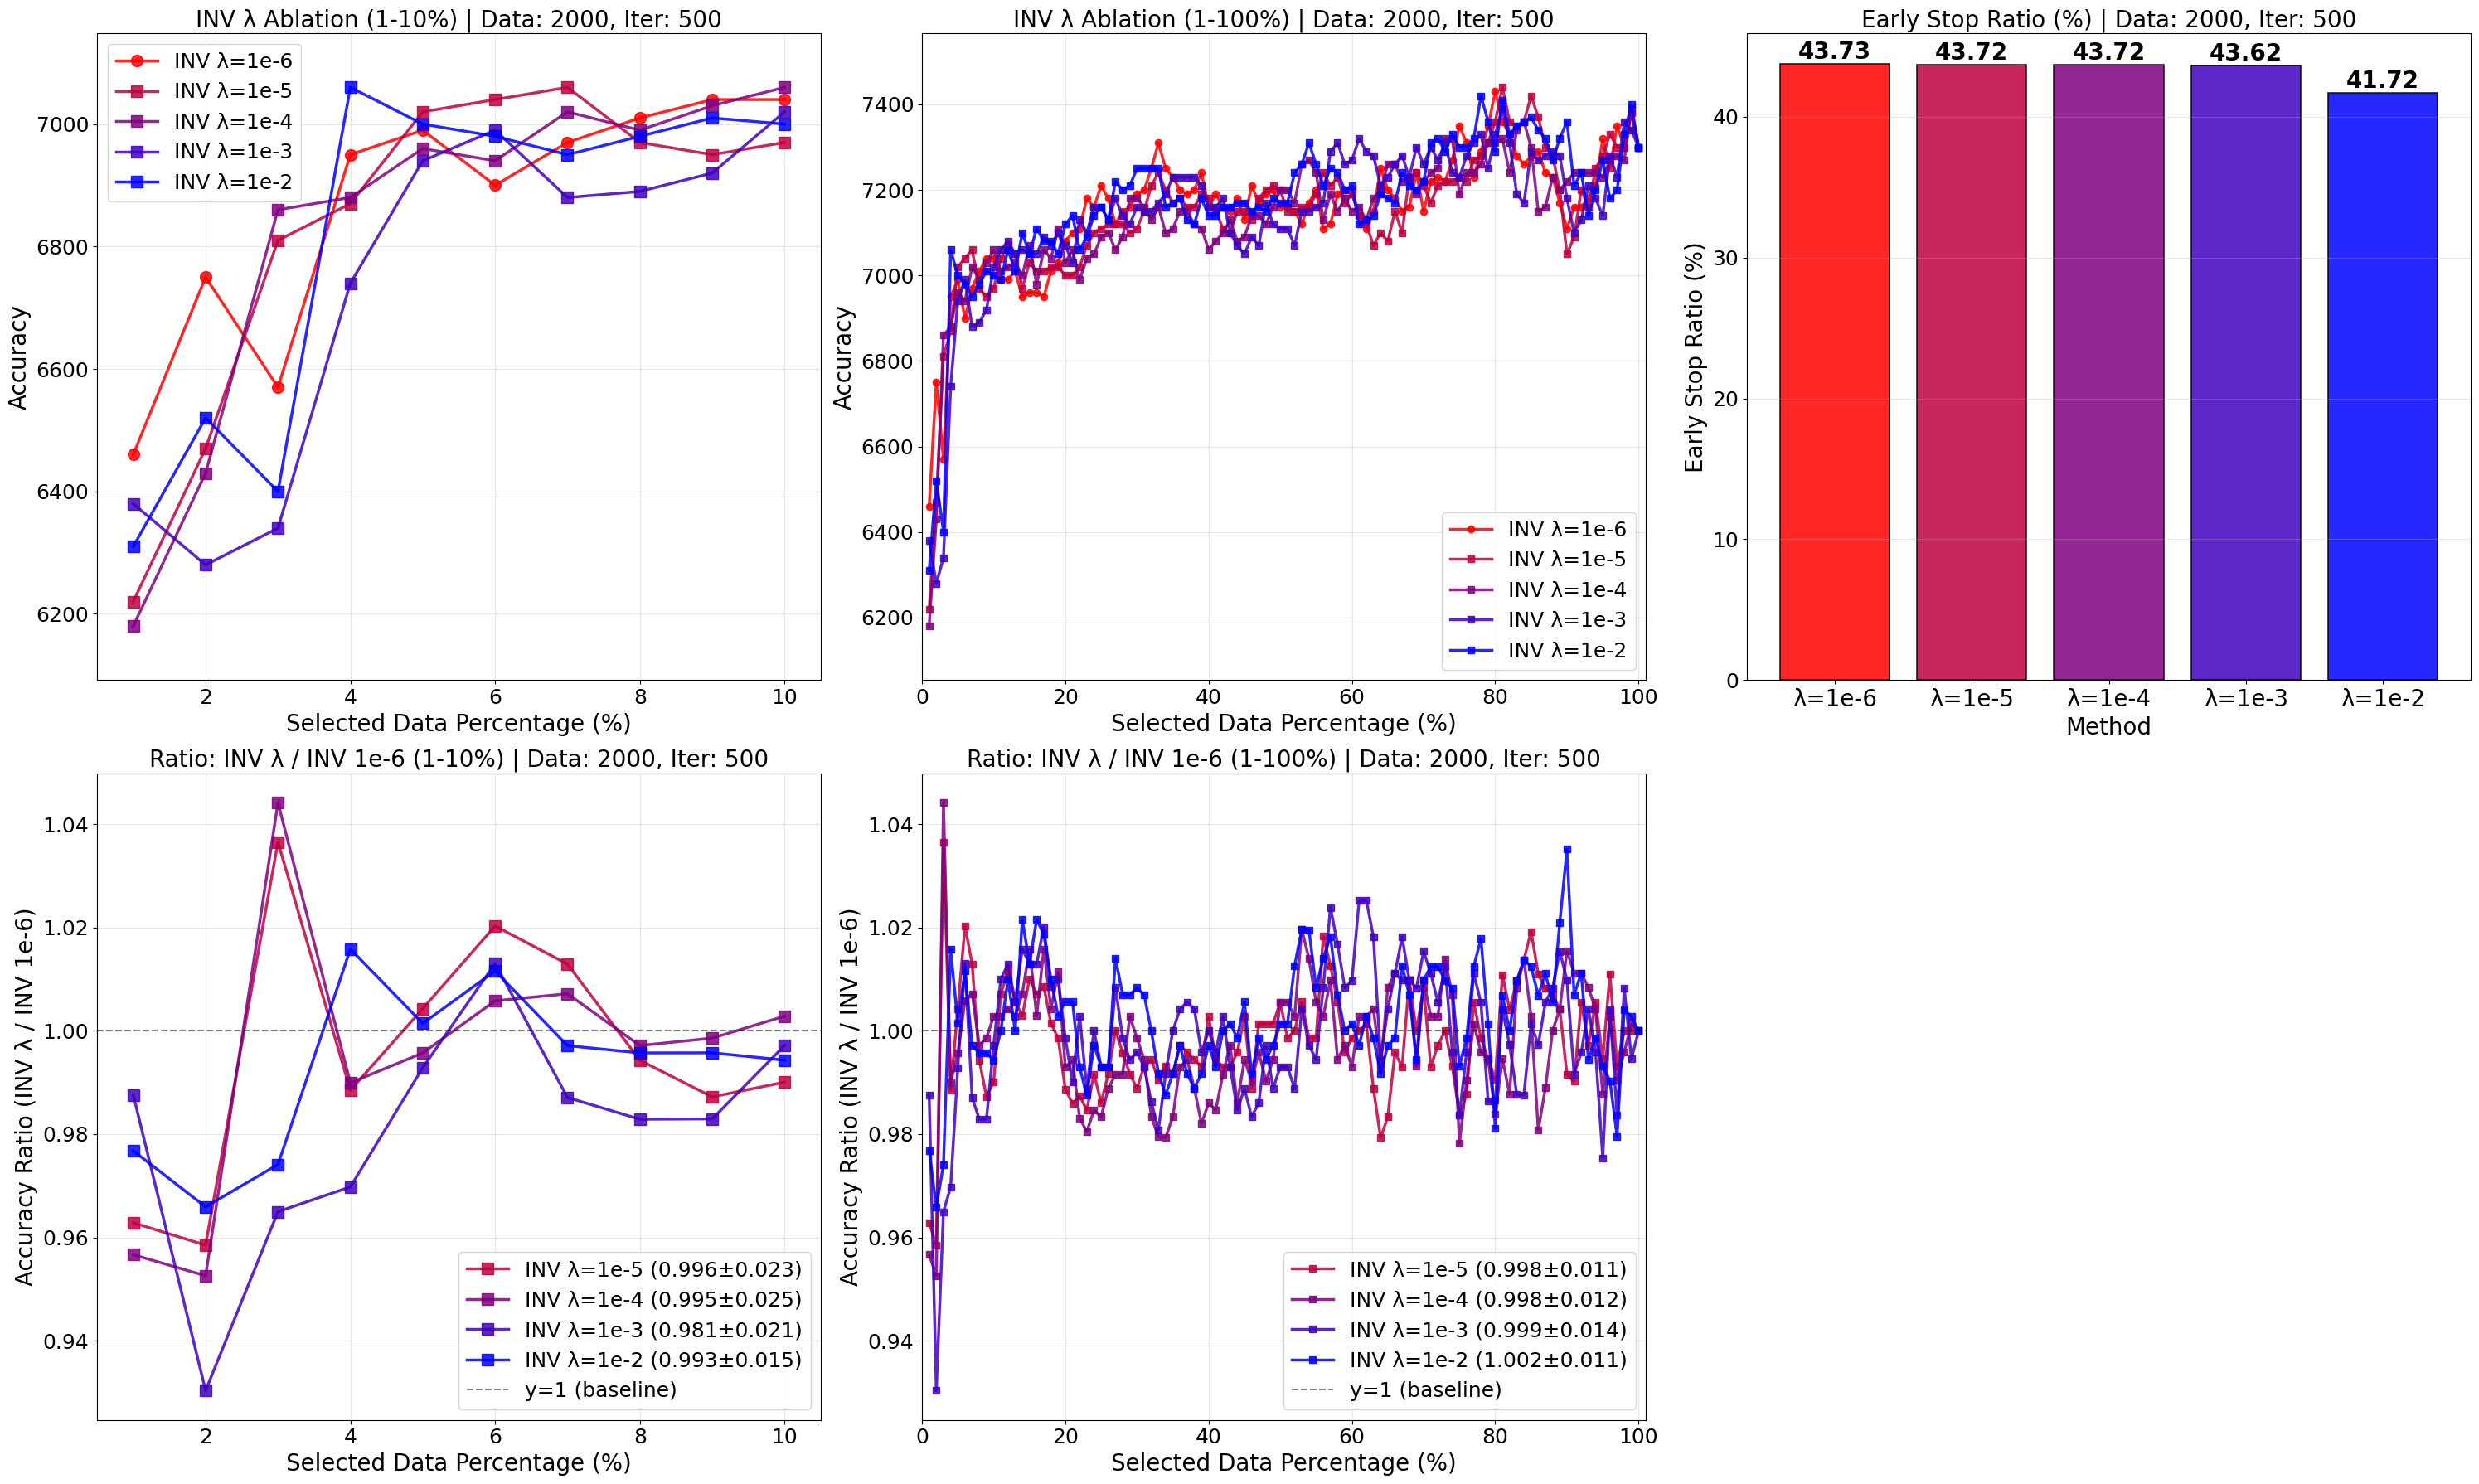

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 2000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = [6460, 6750, 6570, 6950, 6990, 6900, 6970, 7010, 7040, 7040, 6990, 6990, 7010, 6950, 6960, 6960, 6950, 7010, 7030, 7080, 7100, 7110, 7180, 7160, 7210, 7180, 7120, 7150, 7160, 7190, 7200, 7250, 7310, 7250, 7230, 7200, 7190, 7200, 7240, 7160, 7190, 7160, 7150, 7180, 7130, 7210, 7170, 7190, 7200, 7160, 7160, 7150, 7120, 7170, 7200, 7110, 7120, 7190, 7200, 7200, 7140, 7110, 7150, 7250, 7200, 7180, 7150, 7160, 7240, 7150, 7220, 7230, 7220, 7270, 7350, 7310, 7230, 7290, 7350, 7430, 7360, 7330, 7280, 7260, 7280, 7290, 7240, 7230, 7170, 7110, 7160, 7160, 7180, 7210, 7320, 7250, 7350, 7300, 7380, 7300]
lam1e_5  = [6220, 6470, 6810, 6870, 7020, 7040, 7060, 6970, 6950, 6970, 7040, 7070, 7050, 6970, 7030, 7010, 7010, 7020, 7020, 7000, 7000, 7020, 7070, 7100, 7110, 7120, 7120, 7120, 7100, 7110, 7150, 7210, 7240, 7200, 7170, 7180, 7160, 7160, 7190, 7180, 7150, 7110, 7100, 7150, 7150, 7130, 7180, 7200, 7210, 7200, 7150, 7150, 7160, 7160, 7190, 7240, 7210, 7230, 7170, 7190, 7140, 7120, 7070, 7100, 7080, 7150, 7100, 7230, 7240, 7210, 7170, 7210, 7220, 7220, 7230, 7220, 7270, 7280, 7310, 7360, 7440, 7360, 7350, 7360, 7420, 7370, 7300, 7280, 7200, 7050, 7090, 7200, 7160, 7250, 7280, 7330, 7300, 7300, 7380, 7300]
lam1e_4  = [6180, 6430, 6860, 6880, 6960, 6940, 7020, 6990, 7030, 7060, 7010, 7020, 7030, 7000, 7070, 6980, 7060, 7040, 7110, 7030, 7060, 6990, 7040, 7050, 7090, 7100, 7060, 7090, 7180, 7180, 7160, 7130, 7160, 7100, 7110, 7150, 7150, 7120, 7110, 7060, 7080, 7100, 7130, 7080, 7090, 7140, 7140, 7120, 7160, 7200, 7200, 7170, 7260, 7270, 7240, 7130, 7190, 7150, 7180, 7150, 7160, 7130, 7180, 7200, 7260, 7260, 7220, 7230, 7190, 7220, 7240, 7250, 7320, 7320, 7190, 7240, 7240, 7260, 7310, 7310, 7320, 7240, 7340, 7360, 7300, 7150, 7160, 7230, 7200, 7220, 7240, 7240, 7240, 7240, 7230, 7270, 7280, 7270, 7390, 7300]
lam1e_3  = [6380, 6280, 6340, 6740, 6940, 6990, 6880, 6890, 6920, 7020, 7060, 7080, 7050, 7060, 7050, 7050, 7090, 7070, 7100, 7070, 7030, 7130, 7100, 7160, 7160, 7130, 7180, 7140, 7120, 7160, 7150, 7150, 7170, 7190, 7230, 7230, 7230, 7230, 7210, 7160, 7160, 7180, 7100, 7070, 7050, 7090, 7070, 7170, 7120, 7110, 7110, 7070, 7150, 7150, 7160, 7170, 7290, 7310, 7260, 7270, 7320, 7290, 7280, 7210, 7230, 7260, 7280, 7230, 7300, 7260, 7300, 7270, 7310, 7240, 7230, 7280, 7310, 7330, 7250, 7330, 7390, 7310, 7190, 7170, 7290, 7270, 7280, 7290, 7280, 7180, 7100, 7130, 7210, 7180, 7140, 7280, 7230, 7360, 7340, 7300]
lam1e_2  = [6310, 6520, 6400, 7060, 7000, 6980, 6950, 6980, 7010, 7000, 6990, 7060, 7010, 7100, 7050, 7110, 7080, 7080, 7050, 7120, 7140, 7060, 7090, 7140, 7160, 7130, 7220, 7200, 7210, 7250, 7250, 7250, 7250, 7160, 7170, 7180, 7130, 7120, 7180, 7140, 7140, 7160, 7160, 7170, 7170, 7150, 7160, 7150, 7180, 7170, 7170, 7240, 7260, 7310, 7260, 7210, 7250, 7240, 7200, 7210, 7120, 7130, 7140, 7190, 7180, 7170, 7240, 7210, 7200, 7220, 7310, 7320, 7290, 7330, 7300, 7300, 7320, 7420, 7360, 7290, 7410, 7330, 7350, 7360, 7370, 7340, 7320, 7270, 7320, 7360, 7210, 7240, 7140, 7200, 7270, 7180, 7200, 7330, 7400, 7300]

lam1e_6_early_stop = [43.73]
lam1e_5_early_stop = [43.72]
lam1e_4_early_stop = [43.72]
lam1e_3_early_stop = [43.62]
lam1e_2_early_stop = [41.72]

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

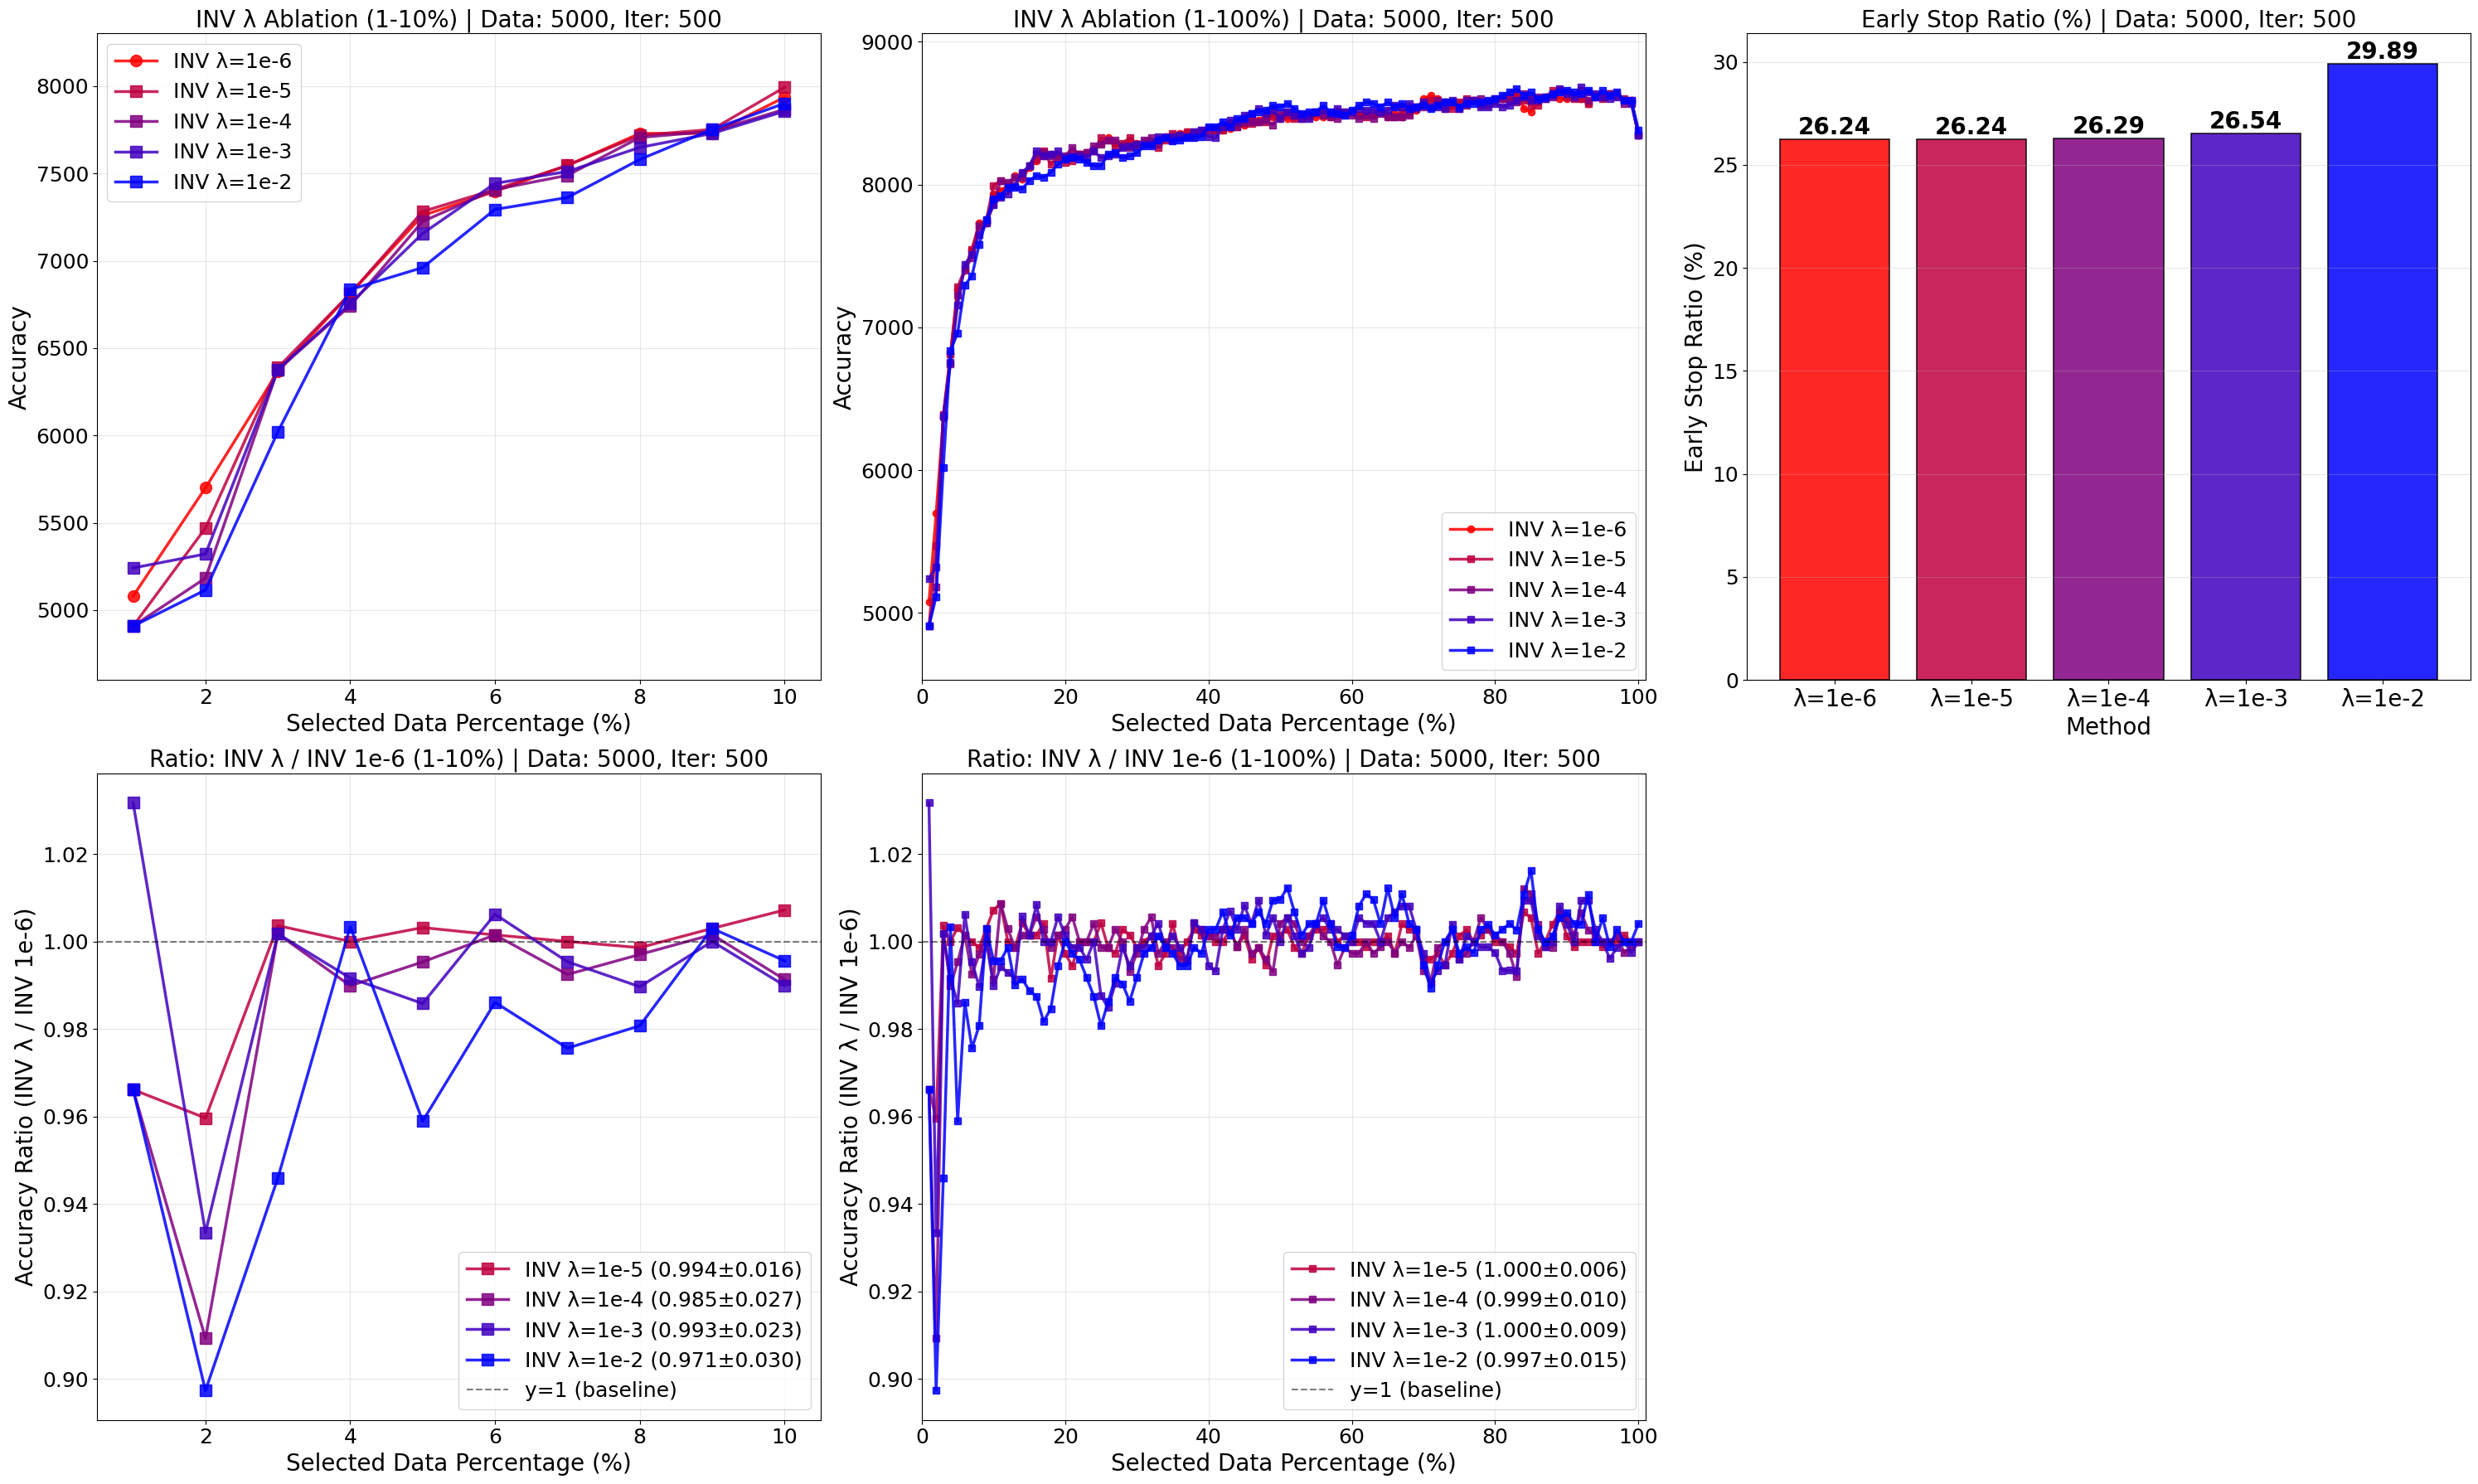

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 5000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ===== Configuration =====
num_dp = 10000
iteration = 500
# =========================

selected_dp_percent = [i for i in range(1, 101)]

# inv lambda: variable, inv lambda: fixed(1e-6)
lam1e_6  = 
lam1e_5  = 
lam1e_4  = 
lam1e_3  = 
lam1e_2  = 

lam1e_6_early_stop = []
lam1e_5_early_stop = []
lam1e_4_early_stop = []
lam1e_3_early_stop = []
lam1e_2_early_stop = []

# ===== Color scheme: λ=1e-6 (red) ~ λ=1e-2 (blue) interpolation =====
color_1e_6 = np.array(mcolors.to_rgb('red'))
color_1e_2 = np.array(mcolors.to_rgb('blue'))

def interp_color(t):
    return tuple((1 - t) * color_1e_6 + t * color_1e_2)

# λ=1e-6: t=0 (red), λ=1e-5: t=0.25, λ=1e-4: t=0.5, λ=1e-3: t=0.75, λ=1e-2: t=1.0 (blue)
lam_colors = {
    '1e-6': interp_color(0.0),
    '1e-5': interp_color(0.25),
    '1e-4': interp_color(0.5),
    '1e-3': interp_color(0.75),
    '1e-2': interp_color(1.0),
}

# Data and labels for comparison (λ=1e-5 ~ 1e-2 vs baseline λ=1e-6)
inv_data = [
    (lam1e_5, 'INV λ=1e-5', lam_colors['1e-5']),
    (lam1e_4, 'INV λ=1e-4', lam_colors['1e-4']),
    (lam1e_3, 'INV λ=1e-3', lam_colors['1e-3']),
    (lam1e_2, 'INV λ=1e-2', lam_colors['1e-2']),
]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(30, 18))
axes = axes.flatten()

plot_percent_10 = selected_dp_percent[:10]

# ===== Subplot (1,1): INV λ별 prediction accuracy, 1~10% =====
ax1 = axes[0]

ax1.plot(plot_percent_10, lam1e_6[:10], color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax1.plot(plot_percent_10, data[:10], color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [lam1e_6[:10]] + [d[0][:10] for d in inv_data]
y_min_10 = min([min(d) for d in all_data_10])
y_max_10 = max([max(d) for d in all_data_10])
y_margin_10 = (y_max_10 - y_min_10) * 0.1
ylim_10_min = y_min_10 - y_margin_10
ylim_10_max = y_max_10 + y_margin_10

ax1.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax1.set_ylabel('Accuracy', fontsize=20)
ax1.set_title(f'INV λ Ablation (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax1.legend(fontsize=18, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.5, 10.5)
ax1.set_ylim(ylim_10_min, ylim_10_max)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): INV λ별 prediction accuracy, 1~100% =====
ax2 = axes[1]

ax2.plot(selected_dp_percent, lam1e_6, color=lam_colors['1e-6'], linewidth=2.5,
         linestyle='-', marker='o', markersize=6, label='INV λ=1e-6', alpha=0.85)

for data, label, color in inv_data:
    ax2.plot(selected_dp_percent, data, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6, label=label, alpha=0.85)

all_data_100 = [lam1e_6] + [d[0] for d in inv_data]
y_min_100 = min([min(d) for d in all_data_100])
y_max_100 = max([max(d) for d in all_data_100])
y_margin_100 = (y_max_100 - y_min_100) * 0.1
ylim_100_min = y_min_100 - y_margin_100
ylim_100_max = y_max_100 + y_margin_100

ax2.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax2.set_ylabel('Accuracy', fontsize=20)
ax2.set_title(f'INV λ Ablation (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax2.legend(fontsize=18, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 101)
ax2.set_ylim(ylim_100_min, ylim_100_max)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['λ=1e-6', 'λ=1e-5', 'λ=1e-4', 'λ=1e-3', 'λ=1e-2']
method_values = [
    lam1e_6_early_stop[0],
    lam1e_5_early_stop[0],
    lam1e_4_early_stop[0],
    lam1e_3_early_stop[0],
    lam1e_2_early_stop[0],
]
bar_colors = [lam_colors['1e-6'], lam_colors['1e-5'], lam_colors['1e-4'], lam_colors['1e-3'], lam_colors['1e-2']]

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Ratio (INV 1e-X / INV 1e-6), 1~10% =====
ax4 = axes[3]

for data, label, color in inv_data:
    ratios = np.array(data[:10]) / np.array(lam1e_6[:10])
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax4.plot(plot_percent_10, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=10,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax4.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax4.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax4.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax4.set_title(f'Ratio: INV λ / INV 1e-6 (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=18, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Ratio (INV 1e-X / INV 1e-6), 1~100% =====
ax5 = axes[4]

for data, label, color in inv_data:
    ratios = np.array(data) / np.array(lam1e_6)
    ratio_mean = np.mean(ratios)
    ratio_std = np.std(ratios)
    ax5.plot(selected_dp_percent, ratios, color=color, linewidth=2.5,
             linestyle='-', marker='s', markersize=6,
             label=f'{label} ({ratio_mean:.3f}±{ratio_std:.3f})', alpha=0.85)

ax5.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=1 (baseline)')

ax5.set_xlabel('Selected Data Percentage (%)', fontsize=20)
ax5.set_ylabel('Accuracy Ratio (INV λ / INV 1e-6)', fontsize=20)
ax5.set_title(f'Ratio: INV λ / INV 1e-6 (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=18, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0, 101)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.show()